In [1]:
!pip -q install gradio scikit-learn pandas numpy

In [2]:
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import gradio as gr

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
sustainability_data = {
    "category": [
        "Transportation",
        "Transportation",
        "Transportation",
        "Energy",
        "Energy",
        "Energy",
        "Water",
        "Water",
        "Waste",
        "Waste",
        "Plastic",
        "Plastic",
        "Food",
        "Food",
        "Food"
    ],

    "activity": [
        "I travel by car every day",
        "I use public transport",
        "I walk or cycle to nearby places",
        "I leave lights on when I leave the room",
        "I switch off electrical appliances when not needed",
        "I use air conditioning for many hours",
        "I leave the water tap running",
        "I take short showers",
        "I throw waste without separating it",
        "I recycle paper and other materials",
        "I buy bottled water frequently",
        "I carry a reusable shopping bag",
        "I waste a lot of food",
        "I plan my meals and avoid food waste",
        "I eat more plant-based meals"
    ],

    "impact": [
        "High",
        "Low",
        "Very Low",
        "High",
        "Low",
        "High",
        "High",
        "Low",
        "High",
        "Low",
        "High",
        "Very Low",
        "High",
        "Low",
        "Low"
    ],

    "score": [
        80,
        20,
        10,
        75,
        15,
        70,
        75,
        15,
        70,
        15,
        80,
        10,
        75,
        15,
        20
    ],

    "recommendation": [
        "Consider public transport, walking, cycling or carpooling when practical.",
        "Continue using public transportation whenever it works for your needs.",
        "Great choice. Continue walking or cycling for suitable short-distance trips.",
        "Switch off lights when leaving a room and use natural light when practical.",
        "Great habit. Continue switching off unused electrical devices.",
        "Reduce unnecessary AC usage and consider a moderate temperature setting.",
        "Turn off the tap while brushing or when water is not actively needed.",
        "Good water-saving habit. Continue taking shorter showers.",
        "Separate recyclable, organic and general waste where local facilities support it.",
        "Great habit. Continue recycling and separating waste correctly.",
        "Carry a reusable bottle to reduce single-use plastic consumption.",
        "Excellent plastic-reduction habit. Continue using reusable bags.",
        "Plan portions and store leftovers safely to reduce avoidable food waste.",
        "Excellent habit. Continue planning meals and using leftovers responsibly.",
        "Including more plant-based meals can be one way to reduce environmental impact."
    ]
}

eco_df = pd.DataFrame(sustainability_data)

display(eco_df)

,category,activity,impact,score,recommendation
0,Transportation,I travel by car every day,High,80,"Consider public transport, walking, cycling or..."
1,Transportation,I use public transport,Low,20,Continue using public transportation whenever ...
2,Transportation,I walk or cycle to nearby places,Very Low,10,Great choice. Continue walking or cycling for ...
3,Energy,I leave lights on when I leave the room,High,75,Switch off lights when leaving a room and use ...
4,Energy,I switch off electrical appliances when not ne...,Low,15,Great habit. Continue switching off unused ele...
5,Energy,I use air conditioning for many hours,High,70,Reduce unnecessary AC usage and consider a mod...
6,Water,I leave the water tap running,High,75,Turn off the tap while brushing or when water ...
7,Water,I take short showers,Low,15,Good water-saving habit. Continue taking short...
8,Waste,I throw waste without separating it,High,70,"Separate recyclable, organic and general waste..."
9,Waste,I recycle paper and other materials,Low,15,Great habit. Continue recycling and separating...


In [4]:
eco_df.to_csv(
    "sustainability_knowledge.csv",
    index=False
)

print("sustainability_knowledge.csv created successfully!")

sustainability_knowledge.csv created successfully!


In [5]:
from google.colab import files

files.download("sustainability_knowledge.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

print("Text preprocessing function created!")

Text preprocessing function created!


In [7]:
eco_df["processed_activity"] = eco_df["activity"].apply(
    preprocess_text
)

display(
    eco_df[["activity", "processed_activity"]].head()
)

,activity,processed_activity
0,I travel by car every day,i travel by car every day
1,I use public transport,i use public transport
2,I walk or cycle to nearby places,i walk or cycle to nearby places
3,I leave lights on when I leave the room,i leave lights on when i leave the room
4,I switch off electrical appliances when not ne...,i switch off electrical appliances when not ne...


In [8]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

activity_vectors = vectorizer.fit_transform(
    eco_df["processed_activity"]
)

print("TF-IDF model created successfully!")
print("Vector shape:", activity_vectors.shape)

TF-IDF model created successfully!
Vector shape: (15, 45)


In [9]:
def detect_activity(user_text):

    cleaned_text = preprocess_text(user_text)

    user_vector = vectorizer.transform(
        [cleaned_text]
    )

    similarity_scores = cosine_similarity(
        user_vector,
        activity_vectors
    )[0]

    best_index = np.argmax(similarity_scores)

    best_score = similarity_scores[best_index]

    return best_index, best_score

In [10]:
test_input = "I drive my car to college every day"

index, score = detect_activity(test_input)

print("Detected Activity:")
print(eco_df.iloc[index]["activity"])

print("\nCategory:")
print(eco_df.iloc[index]["category"])

print("\nSimilarity Score:")
print(round(score, 3))

Detected Activity:
I travel by car every day

Category:
Transportation

Similarity Score:
0.816


In [11]:
def get_sustainability_level(score):

    if score <= 20:
        return "Excellent"

    elif score <= 40:
        return "Good"

    elif score <= 60:
        return "Moderate"

    elif score <= 80:
        return "Needs Improvement"

    else:
        return "High Environmental Impact"

In [12]:
test_score = 75

print(
    "Sustainability Level:",
    get_sustainability_level(test_score)
)

Sustainability Level: Needs Improvement


In [13]:
def analyze_ecobot(user_text):

    if not user_text or not user_text.strip():
        return {
            "response": "Please describe a daily activity.",
            "category": "Unknown",
            "impact": "Unknown",
            "score": 0,
            "level": "Unknown",
            "confidence": 0
        }

    index, similarity = detect_activity(user_text)

    # Unknown question/activity
    if similarity < 0.15:

        return {
            "response": (
                "I couldn't identify the sustainability activity. "
                "Try describing activities related to transportation, "
                "energy, water, waste, plastic or food."
            ),
            "category": "Unknown",
            "impact": "Unknown",
            "score": 0,
            "level": "Unknown",
            "confidence": similarity
        }

    row = eco_df.iloc[index]

    category = row["category"]
    impact = row["impact"]
    score = int(row["score"])
    recommendation = row["recommendation"]

    level = get_sustainability_level(score)

    return {
        "response": recommendation,
        "category": category,
        "impact": impact,
        "score": score,
        "level": level,
        "confidence": similarity
    }

In [14]:
result = analyze_ecobot(
    "I buy bottled water every day"
)

print("🌱 ECOBOT ANALYSIS")
print("-" * 50)

print("Category:", result["category"])
print("Environmental Impact:", result["impact"])
print("Impact Score:", result["score"], "/ 100")
print("Sustainability Level:", result["level"])
print("Confidence:", round(result["confidence"] * 100, 2), "%")

print("\n💡 Recommendation:")
print(result["response"])

🌱 ECOBOT ANALYSIS
--------------------------------------------------
Category: Plastic
Environmental Impact: High
Impact Score: 80 / 100
Sustainability Level: Needs Improvement
Confidence: 73.36 %

💡 Recommendation:
Carry a reusable bottle to reduce single-use plastic consumption.


In [15]:
def generate_response(user_text):

    result = analyze_ecobot(user_text)

    if result["category"] == "Unknown":
        return result["response"]

    response = f"""
🌱 ECOBOT SUSTAINABILITY ANALYSIS

📌 Category:
{result["category"]}

⚠️ Environmental Impact:
{result["impact"]}

📊 Impact Score:
{result["score"]}/100

🌍 Sustainability Level:
{result["level"]}

🎯 Match Confidence:
{result["confidence"] * 100:.2f}%

💡 Personalized Recommendation:
{result["response"]}
"""

    return response

In [16]:
test_questions = [
    "I use public transport every day",
    "I leave the lights on when I leave my room",
    "I waste a lot of food",
    "I carry a reusable water bottle",
    "I walk to nearby places"
]

for question in test_questions:

    print("=" * 70)
    print("USER:", question)
    print(generate_response(question))

USER: I use public transport every day

🌱 ECOBOT SUSTAINABILITY ANALYSIS

📌 Category:
Transportation

⚠️ Environmental Impact:
Low

📊 Impact Score:
20/100

🌍 Sustainability Level:
Excellent

🎯 Match Confidence:
85.65%

💡 Personalized Recommendation:
Continue using public transportation whenever it works for your needs.

USER: I leave the lights on when I leave my room

🌱 ECOBOT SUSTAINABILITY ANALYSIS

📌 Category:
Energy

⚠️ Environmental Impact:
High

📊 Impact Score:
75/100

🌍 Sustainability Level:
Needs Improvement

🎯 Match Confidence:
100.00%

💡 Personalized Recommendation:
Switch off lights when leaving a room and use natural light when practical.

USER: I waste a lot of food

🌱 ECOBOT SUSTAINABILITY ANALYSIS

📌 Category:
Food

⚠️ Environmental Impact:
High

📊 Impact Score:
75/100

🌍 Sustainability Level:
Needs Improvement

🎯 Match Confidence:
100.00%

💡 Personalized Recommendation:
Plan portions and store leftovers safely to reduce avoidable food waste.

USER: I carry a reusable w

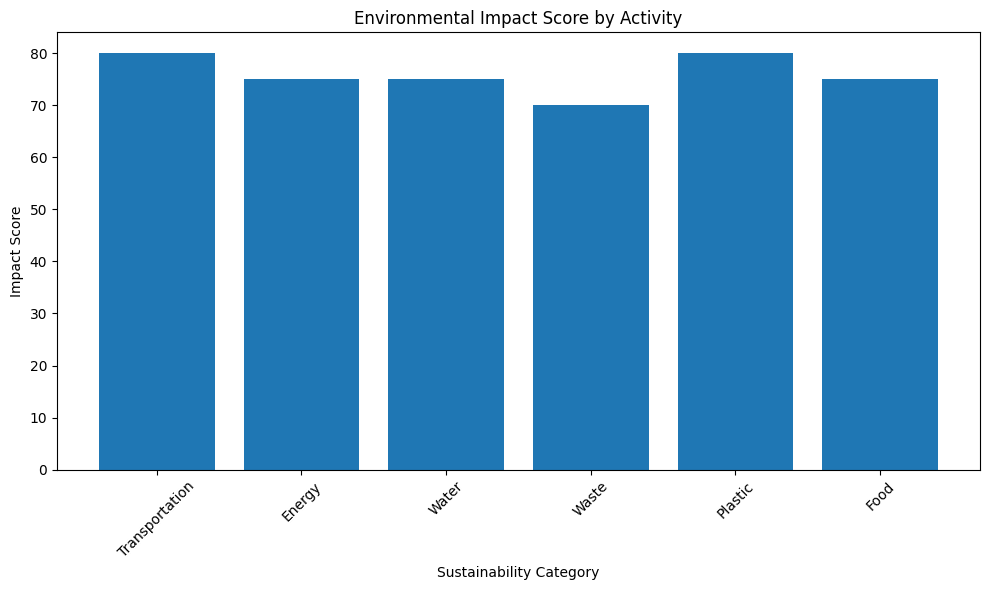

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    eco_df["category"],
    eco_df["score"]
)

plt.title("Environmental Impact Score by Activity")
plt.xlabel("Sustainability Category")
plt.ylabel("Impact Score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

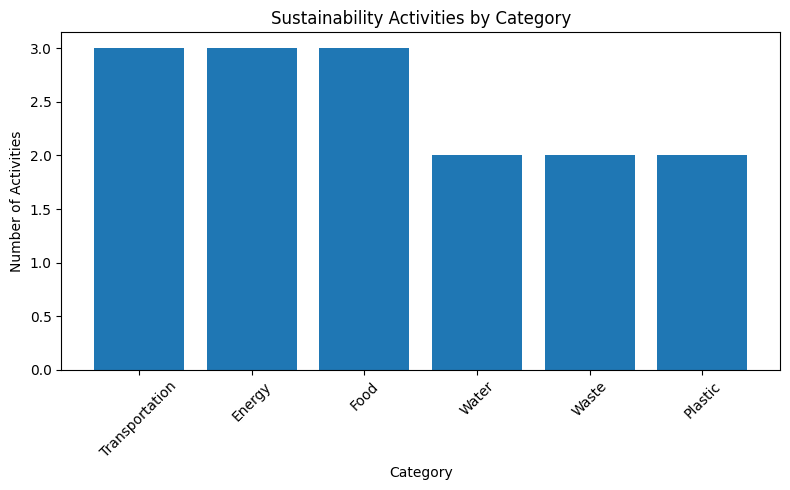

In [18]:
category_counts = eco_df["category"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.title("Sustainability Activities by Category")
plt.xlabel("Category")
plt.ylabel("Number of Activities")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
evaluation_questions = [
    "I travel by car every day",
    "I use public transport",
    "I leave lights on",
    "I switch off appliances",
    "I use air conditioning for many hours",
    "I leave the tap running",
    "I take short showers",
    "I don't separate my waste",
    "I recycle paper",
    "I buy bottled water",
    "I use reusable bags",
    "I waste food",
    "I plan my meals",
    "I eat plant based meals"
]

In [20]:
evaluation_results = []

for question in evaluation_questions:

    result = analyze_ecobot(question)

    evaluation_results.append({
        "User Input": question,
        "Category": result["category"],
        "Impact": result["impact"],
        "Impact Score": result["score"],
        "Sustainability Level": result["level"],
        "Confidence": round(
            result["confidence"] * 100, 2
        )
    })

evaluation_df = pd.DataFrame(
    evaluation_results
)

display(evaluation_df)

,User Input,Category,Impact,Impact Score,Sustainability Level,Confidence
0,I travel by car every day,Transportation,High,80,Needs Improvement,100.00
1,I use public transport,Transportation,Low,20,Excellent,100.00
2,I leave lights on,Energy,High,75,Needs Improvement,84.55
3,I switch off appliances,Energy,Low,15,Excellent,70.71
4,I use air conditioning for many hours,Energy,High,70,Needs Improvement,100.00
5,I leave the tap running,Water,High,75,Needs Improvement,88.60
6,I take short showers,Water,Low,15,Excellent,100.00
7,I don't separate my waste,Food,High,75,Needs Improvement,50.50
8,I recycle paper,Waste,Low,15,Excellent,81.65
9,I buy bottled water,Plastic,High,80,Needs Improvement,85.65


In [21]:
evaluation_df.to_csv(
    "chatbot_evaluation.csv",
    index=False
)

print("chatbot_evaluation.csv created successfully!")

chatbot_evaluation.csv created successfully!


In [22]:
files.download("chatbot_evaluation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
def chat_function(message, history):

    return generate_response(message)

In [24]:
demo = gr.ChatInterface(
    fn=chat_function,

    title="🌱 EcoBot – Personal Sustainability Advisor",

    description=(
        "Describe one of your daily activities and EcoBot "
        "will analyze its environmental impact and provide "
        "a practical sustainability recommendation."
    ),

    examples=[
        "I travel by car every day",
        "I buy bottled water frequently",
        "I leave lights on when I leave the room",
        "I waste a lot of food",
        "I use public transport",
        "I carry a reusable shopping bag",
        "I leave the water tap running"
    ]
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c4f2bd957df3b19361.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [25]:
readme_content = """
# EcoBot – Personal Sustainability Advisor

## Project Overview

EcoBot is an NLP-based Personal Sustainability Advisor that analyzes users' daily activities and provides environmental impact information and personalized sustainability recommendations.

Instead of functioning as a simple question-answer chatbot, EcoBot identifies sustainability-related activities, classifies their environmental impact, calculates an impact score and suggests practical alternatives.

## Features

- NLP-based activity detection
- TF-IDF text vectorization
- Cosine similarity matching
- Environmental category detection
- Impact classification
- Sustainability level prediction
- Impact scoring
- Personalized recommendations
- Confidence score
- Sustainability activity visualization
- Chatbot evaluation
- Interactive Gradio interface
- CSV-based knowledge base

## Sustainability Categories

- Transportation
- Energy
- Water
- Waste
- Plastic
- Food

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- TF-IDF
- Cosine Similarity
- Matplotlib
- Gradio
- Regular Expressions

## System Workflow

User Activity
    ↓
Text Preprocessing
    ↓
TF-IDF Vectorization
    ↓
Cosine Similarity
    ↓
Activity Detection
    ↓
Environmental Category
    ↓
Impact Score
    ↓
Sustainability Level
    ↓
Personalized Recommendation
    ↓
Gradio Chatbot

## Example

User:
I buy bottled water every day.

EcoBot:
Category: Plastic

Environmental Impact: High

Impact Score: 80/100

Sustainability Level: Needs Improvement

Recommendation:
Carry a reusable bottle to reduce single-use plastic consumption.

## Dataset

The project uses sustainability_knowledge.csv as its knowledge base.

## Evaluation

The chatbot is evaluated using a collection of sustainability-related test questions. The evaluation results are stored in chatbot_evaluation.csv.

## Future Improvements

- Add a larger sustainability knowledge base
- Add multilingual support
- Add voice input
- Add voice output
- Add carbon footprint estimation
- Add user sustainability history
- Add personalized sustainability goals
- Integrate real-world environmental datasets
- Deploy as a web application

## Author

Hasini Krishna
"""

with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme_content)

print("README.md created successfully!")

README.md created successfully!


In [26]:
requirements = """
pandas
numpy
scikit-learn
matplotlib
gradio
"""

with open("requirements.txt", "w") as file:
    file.write(requirements.strip())

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [27]:
import os

project_files = [
    "sustainability_knowledge.csv",
    "chatbot_evaluation.csv",
    "README.md",
    "requirements.txt"
]

for file_name in project_files:

    if os.path.exists(file_name):
        print("✓", file_name)

    else:
        print("✗", file_name)

✓ sustainability_knowledge.csv
✓ chatbot_evaluation.csv
✓ README.md
✓ requirements.txt
